# Day 10 - Model Evaluation

## Objectives
- Evaluate the trained Linear Regression model
- Calculate performance metrics
- Visualize prediction results
- Understand model errors

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.style.use("ggplot")

In [6]:
df = pd.read_csv("C:\\Users\\pushp\\OneDrive\\Desktop\\AI &ML project\\student-score-prediction-1\\data\\student_performance_processed.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Study_Efficiency,Academic_Consistency,Healthy_Lifestyle_Index,Exam_Score
0,0.504942,0.348375,-0.254249,-1.380517,-1.214685,-0.019796,-0.143800,-0.393061,0.285825,-1.213934,...,1.070550,0.031411,-0.342867,0.103120,0.717316,0.855746,0.627550,-0.148226,0.001856,67
1,-0.162822,-1.383736,-0.254249,0.913804,-1.214685,0.661399,-1.116110,-0.393061,0.285825,0.411451,...,-1.575587,1.001199,-0.342867,-1.248688,-0.742280,-1.168570,-0.713283,-1.433691,1.116901,61
2,0.671882,1.560853,0.901062,0.913804,0.823259,-0.019796,1.106313,0.884966,0.285825,0.411451,...,-0.252518,1.001199,-0.342867,1.454927,0.717316,0.855746,1.414073,1.458605,0.559379,74
3,1.506587,0.781403,-0.254249,0.913804,0.823259,0.661399,1.592469,0.884966,0.285825,-0.401242,...,-1.575587,1.001199,-0.342867,0.103120,-0.742280,0.855746,1.842914,1.715698,1.116901,71
4,-0.162822,1.041220,0.901062,0.913804,0.823259,-0.700990,-0.699406,0.884966,0.285825,1.224144,...,-0.252518,1.001199,-0.342867,-1.248688,0.717316,-1.168570,0.282978,-0.469593,0.001856,70


In [10]:
target = "Exam_Score"

X = df.drop(columns=[target])

Y = df[target]

In [12]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [14]:
#train model
model = LinearRegression()
model.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
Y_pred = model.predict(X_test)

In [16]:
mae = mean_absolute_error(Y_test,Y_pred)

print("Mean Absolute error (MAE) :", round(mae,2))

Mean Absolute error (MAE) : 0.0


In [18]:
mse = mean_squared_error(Y_test, Y_pred)

print("Mean Squared Error (MSE):", round(mse,2))

Mean Squared Error (MSE): 0.0


In [19]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", round(rmse,2))

Root Mean Squared Error (RMSE): 0.0


In [21]:
r2 = r2_score(Y_test, Y_pred)

print("R² Score:", round(r2,4))

R² Score: 1.0


In [22]:
results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Value": [
        mae,
        mse,
        rmse,
        r2
    ]
})

results

,Metric,Value
0,MAE,9.061839e-15
1,MSE,1.532180e-28
2,RMSE,1.237813e-14
3,R² Score,1.000000e+00


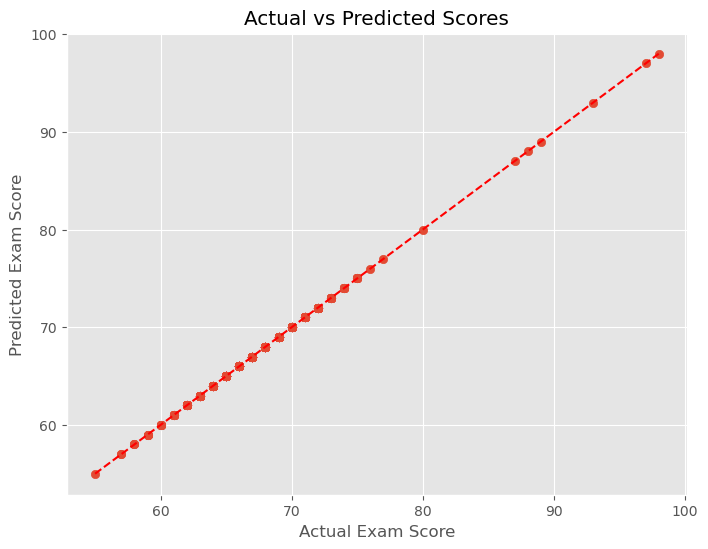

In [23]:
#actual vs predicted scatter plot
plt.figure(figsize = (8,6))

plt.scatter(Y_test,Y_pred)

plt.plot(
    [Y_test.min(),Y_test.max()],
    [Y_test.min(),Y_test.max()],
    'r--'
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Scores")

plt.show()

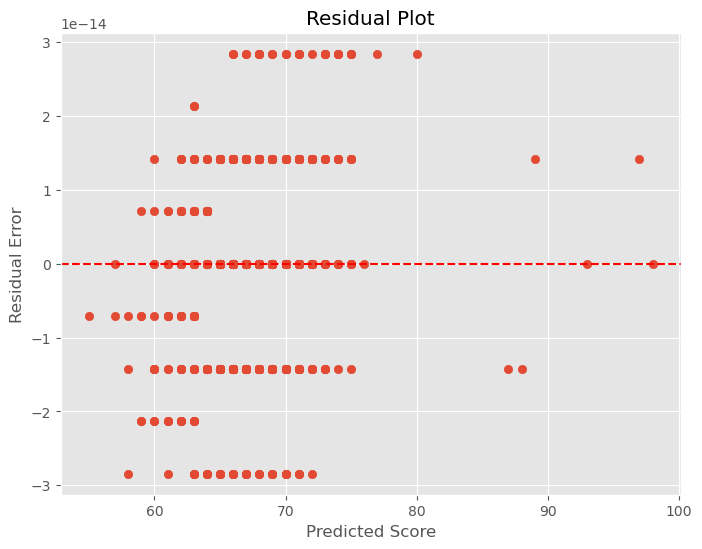

In [25]:
residuals = Y_test - Y_pred

plt.figure(figsize = (8,6))

plt.scatter(Y_pred,residuals)

plt.axhline(
    y=0,
    color="red",
    linestyle= "--"
)

plt.xlabel("Predicted Score")
plt.ylabel("Residual Error")
plt.title("Residual Plot")

plt.show()

In [27]:
comparison = pd.DataFrame({
    "Actual": Y_test.values,
    "Predicted": np.round(Y_pred,2)
})

comparison.head(10)

,Actual,Predicted
0,65,65.0
1,65,65.0
2,71,71.0
3,64,64.0
4,66,66.0
5,66,66.0
6,72,72.0
7,66,66.0
8,70,70.0
9,70,70.0


In [28]:
comparison.to_csv("C:\\Users\\pushp\\OneDrive\\Desktop\\AI &ML project\\student-score-prediction-1\\data\\predictions.csv", index=False
)

print("Prediction results saved successfully.")

Prediction results saved successfully.
